# EVALUATE MOFA-FLEX MANUALLY

# Functions test

In [ ]:
from pathlib import Path
import os
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import json

import matplotlib.pyplot as plt
from sklearn.metrics import (
    normalized_mutual_info_score,
    adjusted_mutual_info_score,
    homogeneity_score,
    adjusted_rand_score,
    silhouette_score,
)
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
)

from docs.source.unfinished_temp_notebooks.MOFA_Flex.helper_functions.Evaluate_mofa_flex_models import spatial_coherence_score

def evaluate_mofaflex(
    model,
    lrdata,
    output_dir,
    group="group_1",
    n_clusters=None,
    obs_keys=("cell_type", "major_brain_region"),
    classification_key=None,
    spatial_key="X_spatial_coords",
    random_state=42,
):
    """
    Run a benchmarking pipeline for a MOFA-FLEX model and save results & figures.

    Parameters
    - model: MOFAFLEX model object (must implement get_factors(), get_weights(), get_r2()).
    - lrdata: AnnData-like object with .obs and .obsm available.
    - output_dir: str or Path where outputs (csv, figs, reports) will be saved.
    - group: group name used when calling model.get_factors()[group].
    - n_clusters: iterable of ints (cluster counts). If None, uses range(2,10).
    - obs_keys: tuple/list of observation keys from lrdata.obs to use for baselines/metrics.
    - classification_key: key in lrdata.obs to use for regression/classification (optional).
    - spatial_key: key in lrdata.obsm storing spatial coordinates (default "X_spatial_coords").
    - random_state: random seed for clustering / classifiers.

    Returns:
    - dict with paths to saved files and results DataFrame under "results_df".
    """
    out = {}
    outdir = Path(output_dir)
    outdir.mkdir(parents=True, exist_ok=True)

    if n_clusters is None:
        n_clusters = list(range(2, 10))
    else:
        n_clusters = list(n_clusters)

    # 1) Factors and alignment with lrdata
    factors_all = model.get_factors()
    if group not in factors_all:
        raise KeyError(f"group '{group}' not found in model factors")
    factors = factors_all[group].copy()

    # intersect indices and subset
    common_idx = lrdata.obs.index.intersection(factors.index)
    factors = factors.loc[common_idx]
    # standardize factor values for clustering/classification
    X = StandardScaler().fit_transform(factors.values)

    # ensure spatial coords aligned to lrdata.obs
    spatial_coords = np.asarray(lrdata.obsm[spatial_key])
    if spatial_coords.shape[0] != lrdata.obs.shape[0]:
        raise ValueError("spatial coords length does not match lrdata.obs length")

    # helper to compute baseline metrics per obs_key (dropna)
    def _baseline_spatial_and_silhouette(obs_key):
        labels = lrdata.obs[obs_key].astype(str).values
        mask = pd.notna(labels)
        labels_f = labels[mask]
        coords_f = spatial_coords[mask]
        scs = spatial_coherence_score(coords_f, labels_f, k=3)
        try:
            sil = silhouette_score(coords_f, labels_f)
        except Exception:
            sil = float("nan")
        return float(scs), float(sil)

    # baseline pairwise metrics between first two obs_keys if available
    baseline_pair = {}
    if len(obs_keys) >= 2:
        a = lrdata.obs[obs_keys[0]].astype(str).values
        b = lrdata.obs[obs_keys[1]].astype(str).values
        mask = pd.notna(a) & pd.notna(b)
        if mask.sum() > 0:
            baseline_pair["nmi"] = float(normalized_mutual_info_score(a[mask], b[mask]))
            baseline_pair["ami"] = float(adjusted_mutual_info_score(a[mask], b[mask]))
            baseline_pair["homogeneity"] = float(homogeneity_score(a[mask], b[mask]))
            baseline_pair["ari"] = float(adjusted_rand_score(a[mask], b[mask]))
        else:
            baseline_pair = {"nmi": np.nan, "ami": np.nan, "homogeneity": np.nan, "ari": np.nan}

    # compute baselines per obs_key
    baselines = {}
    for k in obs_keys:
        scs, sil = _baseline_spatial_and_silhouette(k)
        baselines[f"baseline_spatial_coherence_{k}"] = scs
        baselines[f"baseline_silhouette_{k}"] = sil

    if baseline_pair:
        baselines.update(
            {
                f"baseline_nmi_{obs_keys[0]}_vs_{obs_keys[1]}": baseline_pair["nmi"],
                f"baseline_ami_{obs_keys[0]}_vs_{obs_keys[1]}": baseline_pair["ami"],
                f"baseline_homogeneity_{obs_keys[0]}_vs_{obs_keys[1]}": baseline_pair["homogeneity"],
                f"baseline_ari_{obs_keys[0]}_vs_{obs_keys[1]}": baseline_pair["ari"],
            }
        )

    # 2) Clustering evaluation across cluster counts
    results = []
    idx_lr = lrdata.obs.index  # full index for lrdata
    for k in n_clusters:
        km = KMeans(n_clusters=k, random_state=random_state)
        preds = km.fit_predict(X)  # aligned to factors.index
        preds_series = pd.Series(preds, index=factors.index, name=f"cluster_{k}")

        # add to factors and lrdata (only for matching idx)
        factors[f"cluster_{k}"] = preds_series
        preds_lr = preds_series.reindex(idx_lr)
        lrdata.obs[f"cluster_{k}"] = preds_lr.values

        # prepare mask to exclude NaNs (cells without cluster assignment)
        labels_full = lrdata.obs[f"cluster_{k}"]
        mask = pd.notna(labels_full)
        labels = labels_full[mask].astype(str).values
        coords = spatial_coords[mask.values]

        # spatial coherence (k=3) and silhouette (on spatial coords)
        scs_clusters = float(spatial_coherence_score(coords, labels, k=3)) if coords.shape[0] > 0 else np.nan
        try:
            sil_clusters = float(silhouette_score(coords, labels)) if coords.shape[0] > 0 else np.nan
        except Exception:
            sil_clusters = float("nan")

        # agreement metrics vs each obs_key
        row = {
            "n_clusters": int(k),
            "n_cells": int(len(lrdata.obs)),
            "largest_cluster_size": int(lrdata.obs[f"cluster_{k}"].value_counts(dropna=True).max()),
            "smallest_cluster_size": int(lrdata.obs[f"cluster_{k}"].value_counts(dropna=True).min()),
            "n_unique_clusters_assigned": int(lrdata.obs[f"cluster_{k}"].value_counts(dropna=True).size),
            "spatial_coherence_clusters_k3": scs_clusters,
            "silhouette_clusters": sil_clusters,
        }

        # compare to each obs_key
        for obs in obs_keys:
            true_labels = lrdata.obs[obs].astype(str).values[mask.values]
            if len(true_labels) == 0:
                nmi = ami = hom = ari = np.nan
            else:
                nmi = normalized_mutual_info_score(true_labels, labels)
                ami = adjusted_mutual_info_score(true_labels, labels)
                hom = homogeneity_score(true_labels, labels)
                ari = adjusted_rand_score(true_labels, labels)
            row.update(
                {
                    f"nmi_vs_{obs}": float(nmi),
                    f"ami_vs_{obs}": float(ami),
                    f"homogeneity_vs_{obs}": float(hom),
                    f"ari_vs_{obs}": float(ari),
                }
            )

        # include baselines
        row.update(baselines)
        results.append(row)

    results_df = pd.DataFrame(results)
    csv_path = outdir / "clustering_metrics.csv"
    results_df.to_csv(csv_path, index=False)
    out["results_df"] = results_df
    out["clustering_csv"] = str(csv_path)

    # 3) Plot metrics (similar to notebook)
    sns.set(style="whitegrid")
    # prepare dynamic plots: spatial coherence, silhouette, and for each metric type across obs_keys
    metric_specs = []
    metric_specs.append(
        {"title": "Spatial coherence (clusters) vs baselines", "cols": ["spatial_coherence_clusters_k3"], "baselines": [(f"baseline_spatial_coherence_{obs_keys[0]}", f"baseline - {obs_keys[0]}")] if obs_keys else []}
    )
    metric_specs.append(
        {"title": "Silhouette (clusters) vs baselines", "cols": ["silhouette_clusters"], "baselines": [(f"baseline_silhouette_{obs_keys[0]}", f"baseline - {obs_keys[0]}")] if obs_keys else []}
    )
    # add NMI/AMI/Hom/ARI with all provided obs_keys
    for metric_name in ["nmi", "ami", "homogeneity", "ari"]:
        cols = [f"{metric_name}_vs_{obs}" for obs in obs_keys]
        bas = []
        # add pair baseline if exists (first two)
        if len(obs_keys) >= 2 and f"baseline_{metric_name}_{obs_keys[0]}_vs_{obs_keys[1]}" in baselines:
            bas = [(f"baseline_{metric_name}_{obs_keys[0]}_vs_{obs_keys[1]}", f"baseline ({obs_keys[0]} vs {obs_keys[1]})")]
        metric_specs.append({"title": f"{metric_name.upper()}: cluster vs true labels", "cols": cols, "baselines": bas})

    # create combined figure
    n_plots = len(metric_specs)
    ncols = 2
    nrows = (n_plots + 1) // ncols
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(14, 4 * nrows), squeeze=False)
    baseline_colors = ["gray", "black", "tab:orange", "tab:green"]
    baseline_linestyles = ["--", ":", "-.", "-"]

    for i, spec in enumerate(metric_specs):
        ax = axes[i // ncols, i % ncols]
        for col in spec["cols"]:
            if col in results_df.columns:
                ax.plot(results_df["n_clusters"], results_df[col], marker="o", label=col)
        for j, (bl_col, bl_label) in enumerate(spec.get("baselines", [])):
            if bl_col in results_df.columns:
                bl_val = float(results_df[bl_col].iloc[0])
                color = baseline_colors[j % len(baseline_colors)]
                ls = baseline_linestyles[j % len(baseline_linestyles)]
                ax.axhline(bl_val, color=color, linestyle=ls, linewidth=1.5, label=bl_label)
        ax.set_xlabel("n_clusters")
        ax.set_xticks(results_df["n_clusters"])
        ax.set_title(spec["title"])
        ax.legend(loc="best", fontsize="small")
        ax.grid(axis="y", linestyle=":", alpha=0.6)

    # hide unused axes
    total_axes = nrows * ncols
    for j in range(n_plots, total_axes):
        fig.delaxes(axes[j // ncols, j % ncols])

    fig.tight_layout()
    metrics_path = outdir / "clustering_metrics_summary.png"
    fig.savefig(metrics_path, dpi=150)
    plt.close(fig)
    out["clustering_metrics_plot"] = str(metrics_path)

    # 4) Weight distributions and model diagnostics
    try:
        weights_dict = model.get_weights()
        fig = plt.figure(figsize=(8, 5))
        for key, df in weights_dict.items():
            values = df.values.flatten()
            sns.kdeplot(values, label=str(key), fill=False)
        plt.title("Distribution of Weights per View")
        plt.xlabel("Weight Value")
        plt.ylabel("Density")
        plt.legend(title="View/Key", bbox_to_anchor=(1.05, 1), loc="upper left")
        plt.tight_layout()
        wpath = outdir / "weights_distribution.png"
        fig.savefig(wpath, dpi=150)
        plt.close(fig)
        out["weights_distribution"] = str(wpath)
    except Exception:
        out["weights_distribution"] = None

    # --- Factor correlation (library-agnostic) ---
    try:
        fac = model.get_factors()[group].copy()  # cells x factors (columns are factors)
        # Ensure fac is a DataFrame
        if not isinstance(fac, pd.DataFrame):
            fac = pd.DataFrame(fac)
        corr = fac.corr(method="pearson")  # factor-factor correlation

        fig, ax = plt.subplots(figsize=(6, 5))
        im = ax.imshow(corr.values, aspect="auto", interpolation="nearest")
        ax.set_xticks(range(corr.shape[1]))
        ax.set_xticklabels(corr.columns, rotation=90)
        ax.set_yticks(range(corr.shape[0]))
        ax.set_yticklabels(corr.index)
        cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label("Pearson r")
        ax.set_title("Factor Correlation")
        fig.tight_layout()

        fpath = outdir / "factor_correlation.png"
        fig.savefig(fpath, dpi=150, bbox_inches="tight")
        plt.close(fig)
        out["factor_correlation"] = str(fpath)
    except Exception:
        out["factor_correlation"] = None

# --- Variance explained heatmap: factors (rows) x views (cols) for group_1 ---
    try:
        ve_mat = model.get_r2(ordered=True)["group_1"]  # rows=factors, cols=views
        if isinstance(ve_mat, pd.Series):
            ve_mat = ve_mat.to_frame()
        ve_mat = ve_mat.apply(pd.to_numeric, errors="coerce")
        vmax = float(np.nanmax(ve_mat.values)) if np.isfinite(ve_mat.values).any() else 1.0

        # Scale figure size to content
        fig_w = max(6, 0.48 * ve_mat.shape[1])
        fig_h = max(5, 0.42 * ve_mat.shape[0])

        fig, ax = plt.subplots(figsize=(fig_w, fig_h))
        im = ax.imshow(
            ve_mat.values,
            aspect="auto",
            cmap="Reds_r",   # lighter = higher variance (as in your example)
            vmin=0.0,
            vmax=vmax,
            interpolation="nearest",
        )

        # Ticks & labels
        ax.set_xticks(np.arange(ve_mat.shape[1]))
        ax.set_xticklabels(ve_mat.columns, rotation=90)
        ax.set_yticks(np.arange(ve_mat.shape[0]))
        ax.set_yticklabels(ve_mat.index)

        # Title strip & colorbar like the example
        ax.set_title("group_1", pad=10)
        cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.08)
        cbar.set_label("Variance explained")

        fig.tight_layout()
        vpath = outdir / "variance_explained.png"
        fig.savefig(vpath, dpi=150, bbox_inches="tight")
        plt.close(fig)
        out["variance_explained"] = str(vpath)
    except Exception:
        out["variance_explained"] = None

    # save R2 summary if available
    try:
        r2 = model.get_r2(total=True)
        r2_path = outdir / "r2_summary.csv"
        r2.to_csv(r2_path)
        out["r2_summary"] = str(r2_path)
    except Exception:
        out["r2_summary"] = None

    # 5) Classification (optional)
    if classification_key is not None:
        # build factors with annotation, drop NaNs
        fac = model.get_factors()[group].copy()
        fac["anno"] = lrdata.obs[classification_key].reindex(fac.index)
        fac = fac.dropna(subset=["anno"])
        Xc = fac.drop(columns=["anno"]).values
        y = fac["anno"].values

        X_train, X_test, y_train, y_test = train_test_split(
            Xc, y, test_size=0.3, random_state=random_state, stratify=y
        )
        clf = LogisticRegression(solver="lbfgs", max_iter=2000, class_weight="balanced", multi_class="multinomial")
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        crep = classification_report(y_test, y_pred, output_dict=False)
        # save report
        report_path = outdir / "classification_report.txt"
        with open(report_path, "w") as fh:
            fh.write(f"Accuracy: {acc:.4f}\n\n")
            fh.write(crep)
        out["classification_report"] = str(report_path)

        # confusion matrix plot
        cm = confusion_matrix(y_test, y_pred, labels=clf.classes_)
        fig, ax = plt.subplots(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt="d", ax=ax, cmap="Blues", xticklabels=clf.classes_, yticklabels=clf.classes_)
        ax.set_xlabel("Predicted")
        ax.set_ylabel("True")
        ax.set_title("Confusion matrix")
        cm_path = outdir / "confusion_matrix.png"
        fig.savefig(cm_path, dpi=150, bbox_inches="tight")
        plt.close(fig)
        out["confusion_matrix"] = str(cm_path)

        # multiclass ROC AUC (OvR) if possible
        try:
            y_proba = clf.predict_proba(X_test)
            auc_macro = roc_auc_score(y_test, y_proba, multi_class="ovr", average="macro")
            auc_weighted = roc_auc_score(y_test, y_proba, multi_class="ovr", average="weighted")
            out["classification_auc_macro"] = float(auc_macro)
            out["classification_auc_weighted"] = float(auc_weighted)
            # save numeric summary
            with open(outdir / "classification_metrics.json", "w") as fh:
                json.dump({"accuracy": float(acc), "auc_macro": float(auc_macro), "auc_weighted": float(auc_weighted)}, fh)
        except Exception:
            out["classification_auc_macro"] = None
            out["classification_auc_weighted"] = None

    return out

In [ ]:
merfish_path = Path("/g/stegle/aalsayah/repos/data/merfish/mouse_brain/lrdata")
lrdata = sc.read(merfish_path / "WB_MERFISH_animal2_coronal_lrdata.h5ad")

In [139]:
models_path = Path("/g/stegle/aalsayah/repos/data/merfish/mouse_brain/mofa_models")
model= mfl.MOFAFLEX.load(models_path / "WB_MERFISH_animal2_coronal_Normal.hdf5")
eval_path = Path(models_path / "evaluation_results_Normal")
results_normal = evaluate_mofaflex(
    model,
    lrdata,
    eval_path,
    group="group_1",
    n_clusters=None,
    obs_keys=("cell_type", "major_brain_region"),
    classification_key="major_brain_region",
    spatial_key="X_spatial_coords",
    random_state=42)

/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.


In [137]:
models_path = Path("/g/stegle/aalsayah/repos/data/merfish/mouse_brain/mofa_models")
model_GP_SnS = mfl.MOFAFLEX.load(models_path / "WB_MERFISH_animal2_coronal_GP_SnS.hdf5")
eval_path = Path(models_path / "evaluation_results_GP_SnS")
results_GP_SnS = evaluate_mofaflex(
    model_GP_SnS,
    lrdata,
    eval_path,
    group="group_1",
    n_clusters=None,
    obs_keys=("cell_type", "major_brain_region"),
    classification_key="major_brain_region",
    spatial_key="X_spatial_coords",
    random_state=42)

/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.


In [138]:
models_path = Path("/g/stegle/aalsayah/repos/data/merfish/mouse_brain/mofa_models")
model_nonneg = mfl.MOFAFLEX.load(models_path / "WB_MERFISH_animal2_coronal_nonneg.hdf5")
eval_path = Path(models_path / "evaluation_results_nonneg")
results_nonneg = evaluate_mofaflex(
    model_nonneg,
    lrdata,
    eval_path,
    group="group_1",
    n_clusters=None,
    obs_keys=("cell_type", "major_brain_region"),
    classification_key="major_brain_region",
    spatial_key="X_spatial_coords",
    random_state=42)

/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.


In [140]:
models = {
    "Normal_Priors": results_normal,
    "Non_Negativity": results_nonneg,
    "GP_SnS": results_GP_SnS,
}

In [141]:
import math

def spatial_statistics_summary_plot(models_dict, obs_keys=("cell_type", "major_brain_region"), figsize=(14, 12), ncols=2):
    """
    Line plot summary of spatial/clustering metrics across models.
    - models_dict: mapping name -> dict (must include 'results_df' DataFrame with same columns)
    - obs_keys: tuple (obskey1, obskey2). Creates one figure per obs_key (facet).
    Notes:
      - columns expected in each results_df:
          - 'n_clusters'
          - 'spatial_coherence_clusters_k3', 'silhouette_clusters'
          - '{metric}_vs_{obskey}' for metric in ['nmi','ami','homogeneity','ari']
          - baseline columns starting with 'baseline_...'
      - Baseline horizontal lines are drawn when matching baseline columns are found.
    """

    metric_types = [
        ("spatial_coherence_clusters_k3", "Spatial coherence (k=3)"),
        ("silhouette_clusters", "Silhouette (spatial)"),
        ("nmi", "NMI"),
        ("ami", "AMI"),
        ("homogeneity", "Homogeneity"),
        ("ari", "ARI"),
    ]

    # pick a reference results_df to detect baseline column names (assume shared across models)
    ref_df = None
    for v in models_dict.values():
        if isinstance(v, dict) and "results_df" in v and isinstance(v["results_df"], pd.DataFrame):
            ref_df = v["results_df"]
            break
    if ref_df is None:
        raise ValueError("No results_df found in models_dict entries")

    # helper to find baseline column for a given metric (returns column name or None)
    def _find_baseline_col(metric):
        candidates = [c for c in ref_df.columns if c.startswith("baseline_") and metric in c]
        return candidates[0] if candidates else None

    # For each obs_key create a multi-panel figure (one subplot per metric type)
    for obs in obs_keys:
        n_plots = len(metric_types)
        nrows = math.ceil(n_plots / ncols)
        fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize, squeeze=False)
        fig.suptitle(f"Spatial / Agreement metrics (obs_key: {obs})", fontsize=14)

        for i, (mkey, mlabel) in enumerate(metric_types):
            ax = axes[i // ncols, i % ncols]

            # determine the column name in results_df for this metric and obs
            if mkey in ["spatial_coherence_clusters_k3", "silhouette_clusters"]:
                col_name = mkey
            else:
                col_name = f"{mkey}_vs_{obs}"

            # plot each model's line (skip if column missing)
            any_plotted = False
            for model_name, mdl in models_dict.items():
                if not (isinstance(mdl, dict) and "results_df" in mdl):
                    continue
                df = mdl["results_df"]
                if "n_clusters" not in df.columns:
                    continue
                if col_name not in df.columns:
                    # skip this model for this metric
                    continue
                ax.plot(df["n_clusters"], df[col_name], marker="o", label=model_name)
                any_plotted = True

            # plot baseline if available
            # For spatial/silhouette baseline column names include the obs key
            if mkey in ["spatial_coherence_clusters_k3", "silhouette_clusters"]:
                bl_col = f"baseline_spatial_coherence_{obs}" if mkey.startswith("spatial") else f"baseline_silhouette_{obs}"
                if bl_col not in ref_df.columns:
                    # fallback - try general search
                    bl_col = _find_baseline_col("spatial_coherence") if mkey.startswith("spatial") else _find_baseline_col("silhouette")
                if bl_col in ref_df.columns:
                    bl_val = float(ref_df[bl_col].iloc[0])
                    ax.axhline(bl_val, color="gray", linestyle="--", linewidth=1.5, label="baseline")
                    any_plotted = True
            else:
                # agreement metrics: baseline is the pair baseline between the two obs_keys
                # search for any baseline column that contains the metric name
                bl_col = _find_baseline_col(mkey)
                if bl_col is not None:
                    bl_val = float(ref_df[bl_col].iloc[0])
                    ax.axhline(bl_val, color="gray", linestyle="--", linewidth=1.5, label="baseline (obs pair)")
                    any_plotted = True

            if not any_plotted:
                ax.text(0.5, 0.5, "no data", ha="center", va="center", transform=ax.transAxes, color="gray")

            ax.set_xlabel("n_clusters")
            ax.set_xticks(ref_df["n_clusters"] if "n_clusters" in ref_df.columns else [])
            ax.set_ylabel(mlabel)
            ax.set_title(mlabel)
            ax.grid(axis="y", linestyle=":", alpha=0.6)
            ax.legend(loc="best", fontsize="small")

        # remove unused axes
        total_axes = nrows * ncols
        for j in range(n_plots, total_axes):
            fig.delaxes(axes[j // ncols, j % ncols])

        fig.tight_layout(rect=[0, 0, 1, 0.96])
        plt.show()

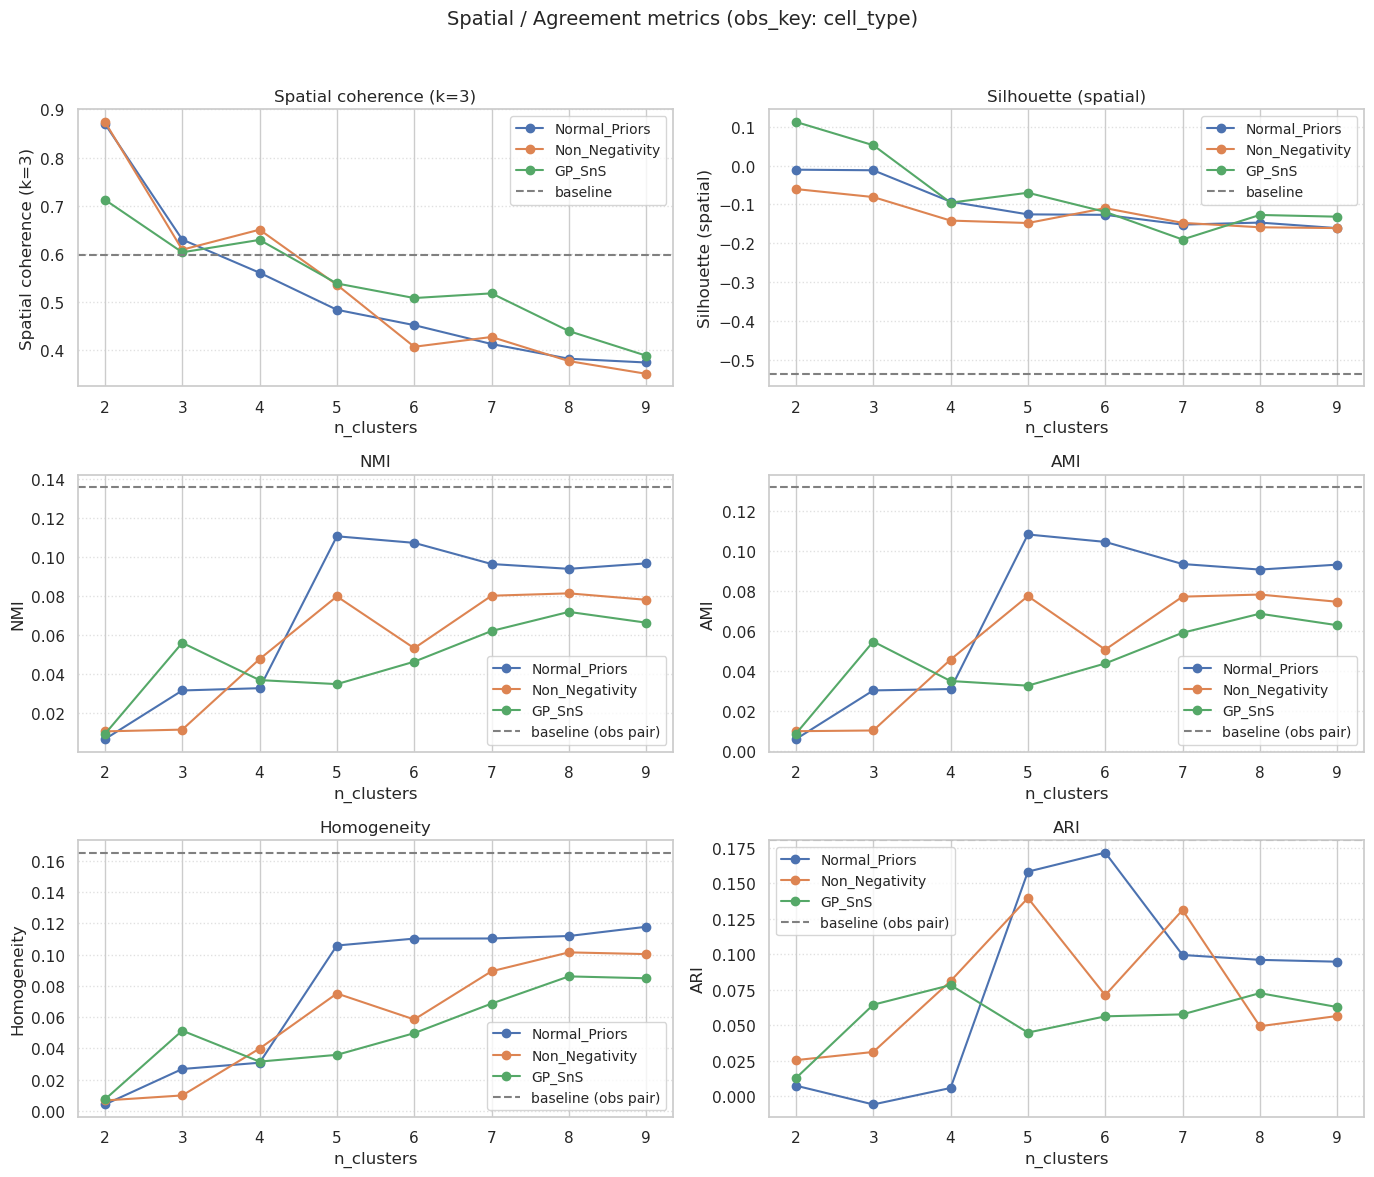

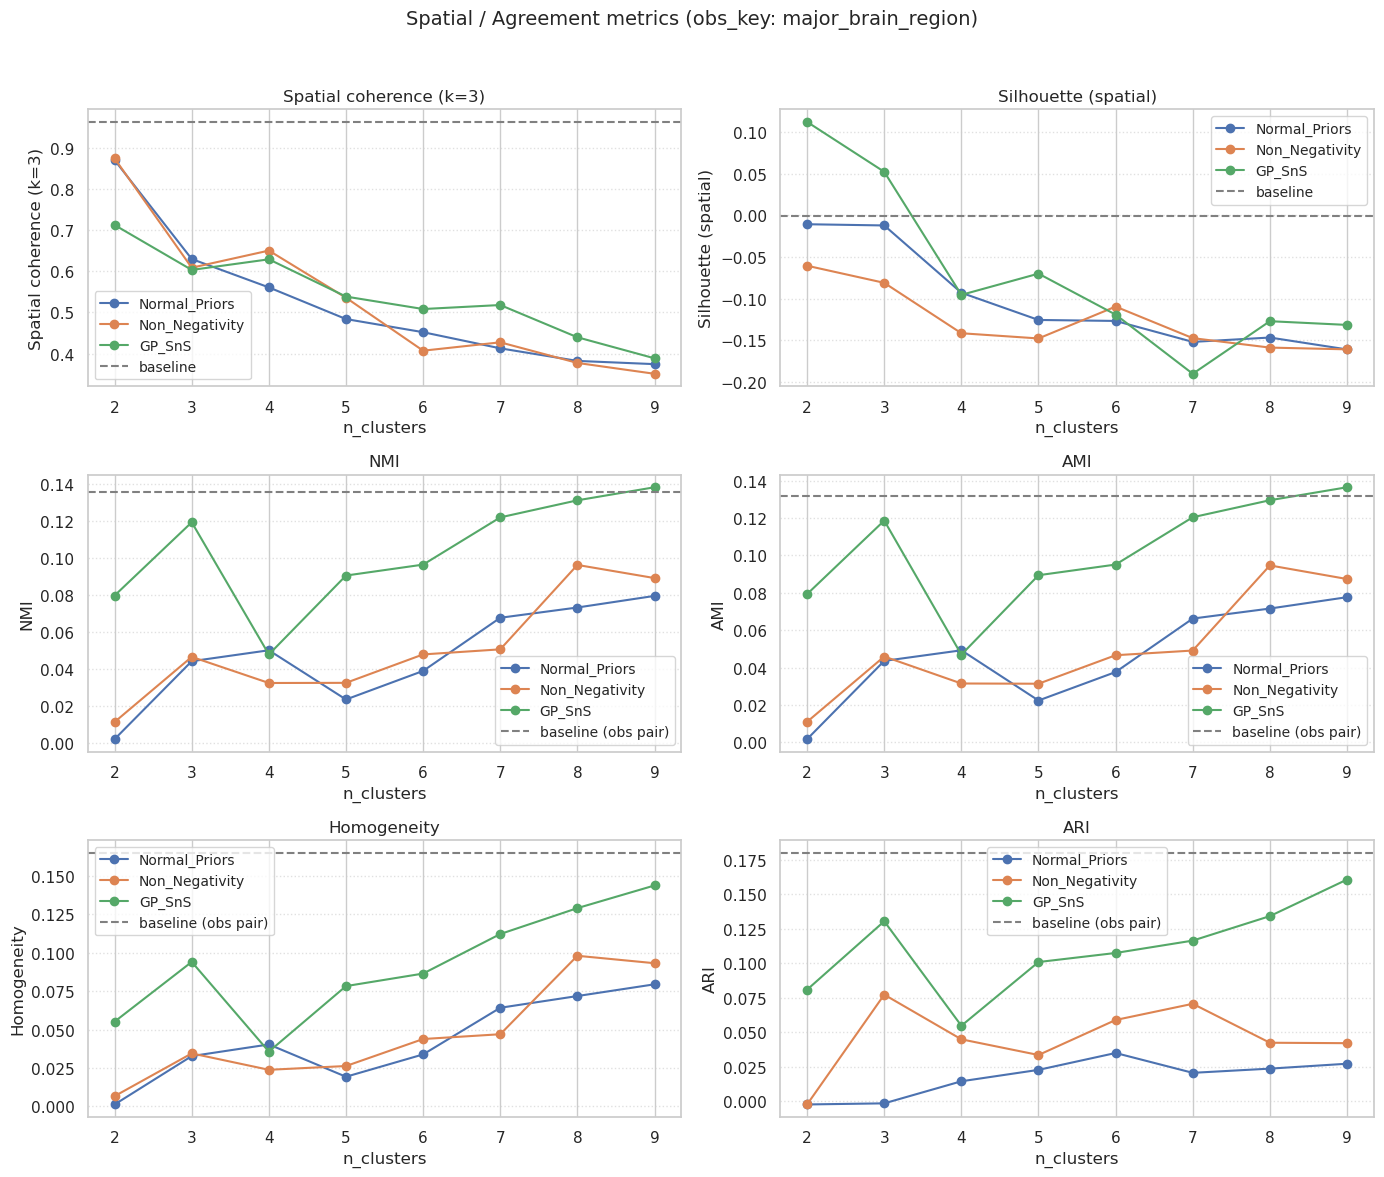

In [142]:
spatial_statistics_summary_plot(models, obs_keys=("cell_type", "major_brain_region"))

In [144]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt

def _read_mean_r2_from_path(p):
    p = Path(p)
    if not p.exists():
        return np.nan
    try:
        df = pd.read_csv(p, index_col=0)
        num = df.select_dtypes(include=[np.number])
        if num.size == 0:
            return np.nan
        # prefer group_1 if present (matches earlier notebook)
        if "group_1" in num.columns:
            return float(num["group_1"].mean())
        # otherwise average across numeric columns
        return float(num.mean(axis=0).mean())
    except Exception:
        return np.nan

def _read_accuracy_from_report(path):
    p = Path(path)
    if not p.exists():
        return np.nan
    try:
        txt = p.read_text().splitlines()
        for ln in txt:
            if ln.strip().lower().startswith("accuracy"):
                # line like "Accuracy: 0.8123"
                parts = ln.split(":")
                if len(parts) >= 2:
                    return float(parts[1].strip())
        # fallback: try JSON metrics file
        return np.nan
    except Exception:
        return np.nan

def _read_metrics_json(path):
    p = Path(path)
    if not p.exists():
        return {}
    try:
        return json.loads(p.read_text())
    except Exception:
        return {}

def model_performance_summary_plot(models_dict, figsize=(8, 4), fmt="{:.3f}", title="Model performance summary"):
    """
    Create a grouped bar plot of model performance across three metrics:
      - Average R2 (mean R2 across views / modalities)
      - Classification accuracy (parsed from classification_report written by evaluate_mofaflex)
      - Classification weighted AUC (classification_auc_weighted or from saved json)

    models_dict: mapping name -> dict produced by evaluate_mofaflex (or similar).
    Returns (df, fig, ax)
    """
    rows = []
    for name, info in models_dict.items():
        mean_r2 = np.nan
        acc = np.nan
        auc_w = np.nan

        # Mean R2: try explicit numeric key, then r2_summary csv path
        if isinstance(info, dict):
            if "mean_r2" in info and pd.notna(info["mean_r2"]):
                mean_r2 = float(info["mean_r2"])
            elif "r2_summary" in info and info["r2_summary"] is not None:
                mean_r2 = _read_mean_r2_from_path(info["r2_summary"])
            # direct r2 dataframe may be provided
            elif "results_df" in info and hasattr(info["results_df"], "attrs") and "mean_r2" in info["results_df"].attrs:
                try:
                    mean_r2 = float(info["results_df"].attrs["mean_r2"])
                except Exception:
                    mean_r2 = np.nan

            # Accuracy: parse classification_report file if present
            if "classification_report" in info and info["classification_report"] is not None:
                acc = _read_accuracy_from_report(info["classification_report"])
            # try JSON metrics file or keys
            if "classification_metrics.json" in info and info["classification_metrics.json"] is not None:
                jm = _read_metrics_json(info["classification_metrics.json"])
                acc = acc if not np.isnan(acc) else jm.get("accuracy", acc)
                auc_w = jm.get("auc_weighted", auc_w)
            # direct numeric keys
            if "classification_auc_weighted" in info and pd.notna(info["classification_auc_weighted"]):
                auc_w = float(info["classification_auc_weighted"])
            if "classification_auc_macro" in info and pd.notna(info["classification_auc_macro"]) and np.isnan(auc_w):
                auc_w = float(info["classification_auc_macro"])
            # sometimes a metrics json path is saved under classification_metrics
            if np.isnan(auc_w) and "classification_metrics" in info and info["classification_metrics"] is not None:
                jm = _read_metrics_json(info["classification_metrics"])
                auc_w = jm.get("auc_weighted", auc_w)

        rows.append({"model": name, "mean_r2": mean_r2, "accuracy": acc, "auc_weighted": auc_w})

    df = pd.DataFrame(rows).set_index("model")
    # ensure numeric dtype
    df = df.astype(float)

    # Plot grouped bars: x axis = metrics, groups = metric categories, bars per model
    metrics = ["mean_r2", "accuracy", "auc_weighted"]
    metric_labels = {"mean_r2": "Average R2", "accuracy": "Accuracy", "auc_weighted": "AUC (weighted)"}

    n_metrics = len(metrics)
    n_models = len(df)
    fig, ax = plt.subplots(figsize=figsize)
    palette = sns.color_palette("tab10", n_models)

    bar_width = 0.8 / n_models
    x = np.arange(n_metrics)

    for i, (model_name, row) in enumerate(df.iterrows()):
        vals = [row[m] for m in metrics]
        positions = x - 0.4 + i * bar_width + bar_width / 2
        bars = ax.bar(positions, vals, width=bar_width, label=model_name, color=palette[i])
        # annotate bars
        for b in bars:
            h = b.get_height()
            if np.isnan(h):
                lbl = "n/a"
                ax.text(b.get_x() + b.get_width() / 2, 0.01, lbl, ha="center", va="bottom", fontsize=8, rotation=0)
            else:
                ax.text(b.get_x() + b.get_width() / 2, h + max(0.01, 0.01 * abs(h)), fmt.format(h), ha="center", va="bottom", fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels([metric_labels.get(m, m) for m in metrics])
    ax.set_ylabel("Value")
    ax.set_title(title)
    ax.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
    ax.set_ylim(bottom=0)  # performance metrics are non-negative here
    fig.tight_layout()
    return df, fig, ax



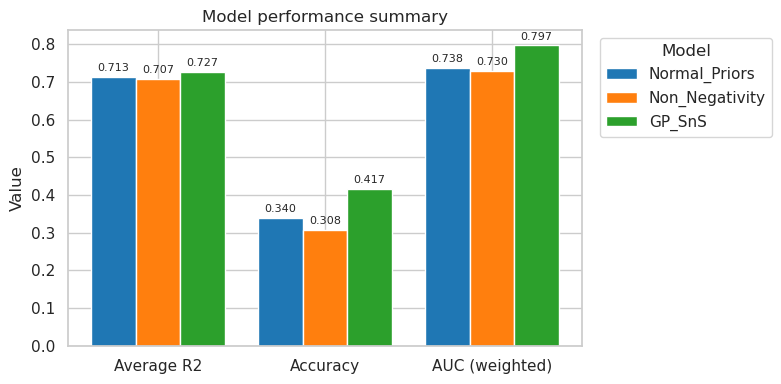

In [145]:
# Example usage (run in notebook cell):
df_perf, fig, ax = model_performance_summary_plot(models)
plt.show()

# FULL Breakdown

In [82]:
import os
import sys
import scanpy as sc
from pathlib import Path
import mofaflex as mfl
import pandas as pd

import os.path
import anndata as ad
import mudata as md
import numpy as np
import pandas as pd
import mofaflex as mfl
from plotnine import *
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
from umap import UMAP
from sklearn.manifold import TSNE

sys.path.append("docs/source/unfinished_temp_notebooks/MOFA_Flex/")

In [2]:
from helper_functions import evaluate_pipeline
from helper_functions import plot_model_metrics
from helper_functions import summarize_cluster_spatial_metrics

In [3]:
models_path = Path("/g/stegle/aalsayah/repos/data/merfish/mouse_brain/mofa_models")
merfish_path = Path("/g/stegle/aalsayah/repos/data/merfish/mouse_brain/lrdata")
lrdata = sc.read(merfish_path / "WB_MERFISH_animal2_coronal_lrdata.h5ad")
model= mfl.MOFAFLEX.load(models_path / "WB_MERFISH_animal2_coronal_Normal.hdf5")

## 1. Model performance and Overview

### 1.1 Factor Correlation

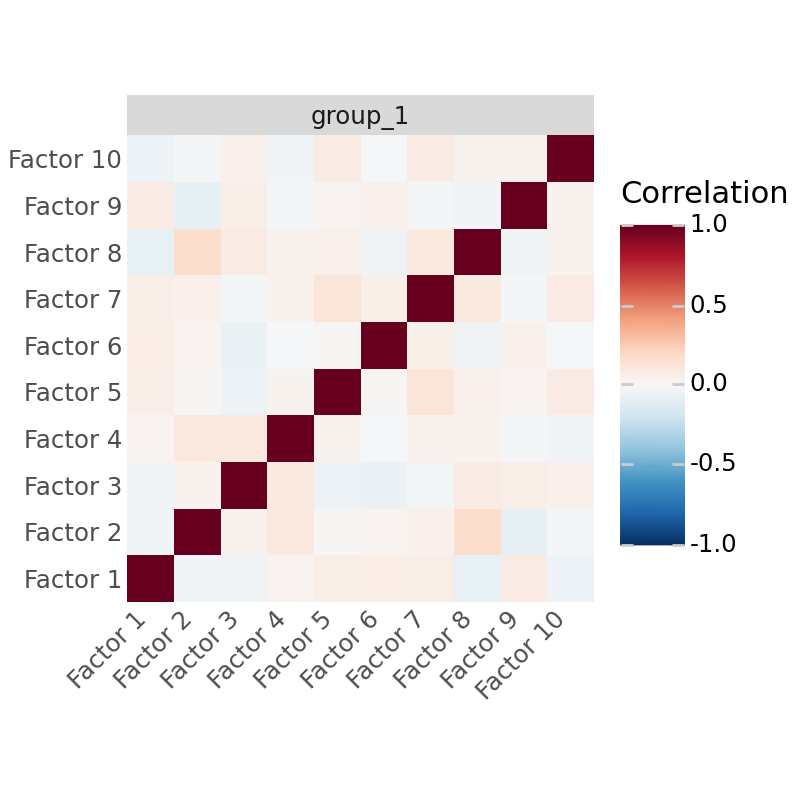

In [55]:
mfl.pl.factor_correlation(model, figsize=(4, 4))

### 1.2 Variance Explained

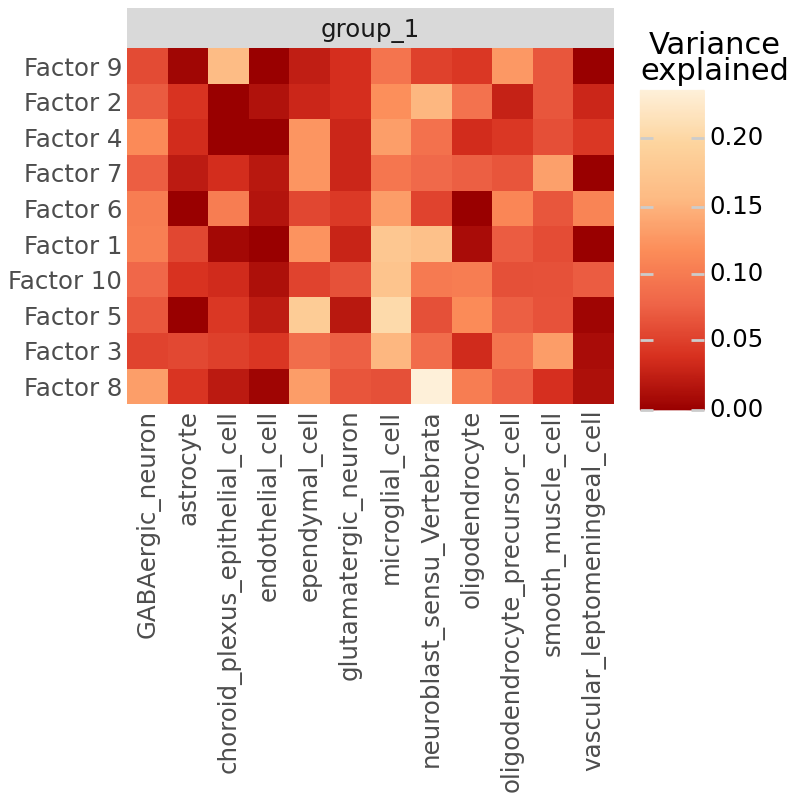

In [56]:
mfl.pl.variance_explained(model, figsize=(4, 4))

### 1.3 Average R2

In [59]:
r2 = model.get_r2(total=True)
mean_r2 = float(r2["group_1"].mean())
print(f"Average R2 across all modalities: {mean_r2:.4f}")

Average R2 across all modalities: 0.7135


### 1.4 Weight distribution

In [60]:
weights_dict= model.get_weights()

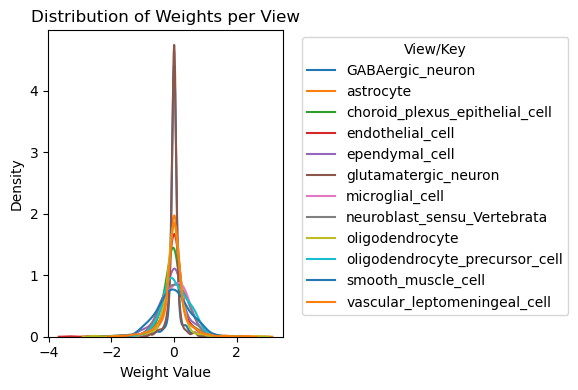

In [62]:
plt.figure(figsize=(6, 4))

# Loop through each view/key
for key, df in weights_dict.items():
    # Flatten all weights from that DataFrame into 1D array
    values = df.values.flatten()
    sns.kdeplot(values, label=key, fill=False)  # distribution curve

plt.title("Distribution of Weights per View")
plt.xlabel("Weight Value")
plt.ylabel("Density")
plt.legend(title="View/Key", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 2. Spatial metrics

### Cluster

In [6]:
from sklearn.metrics import *
import pandas as pd
from tqdm.auto import tqdm
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors

In [ ]:
import pandas as pd

# Run KMeans for k in 2..12, compute spatial + clustering metrics vs true labels,
# and save results to a dataframe and CSV. Uses existing variables/functions:
# X, factors, lrdata, spatial_coherence_score, and sklearn.metrics functions.

results = []
spatial_coords = lrdata.obsm["X_spatial_coords"]
true_cell = lrdata.obs["cell_type"].astype(str).values
true_region = lrdata.obs["major_brain_region"].astype(str).values
idx_lr = lrdata.obs.index

# Baseline metrics between true labels (will be repeated for each row for convenience)
baseline = {
    "baseline_spatial_coherence_cell_type": spatial_coherence_score(spatial_coords, true_cell, k=3),
    "baseline_spatial_coherence_major_brain_region": spatial_coherence_score(spatial_coords, true_region, k=3),
    "baseline_silhouette_cell_type": silhouette_score(spatial_coords, true_cell),
    "baseline_silhouette_major_brain_region": silhouette_score(spatial_coords, true_region),
    "baseline_nmi_cell_vs_region": normalized_mutual_info_score(true_cell, true_region),
    "baseline_ami_cell_vs_region": adjusted_mutual_info_score(true_cell, true_region),
    "baseline_homogeneity_cell_vs_region": homogeneity_score(true_cell, true_region),
    "baseline_ari_cell_vs_region": adjusted_rand_score(true_cell, true_region),
}

for k in range(2, 13):
    km = KMeans(n_clusters=k, random_state=42)
    preds = km.fit_predict(X)                       # aligned to factors.index
    preds_series = pd.Series(preds, index=factors.index, name=f"cluster_{k}")
    # add to factors (keeps prior 'cluster' col intact)
    factors[f"cluster_{k}"] = preds_series

    # assign to lrdata (only for the intersecting indices that lrdata currently has)
    preds_lr = preds_series.reindex(idx_lr)
    lrdata.obs[f"cluster_{k}"] = preds_lr.values

    # prepare labels for metrics
    labels_lr = lrdata.obs[f"cluster_{k}"].astype(str).values

    # spatial metrics
    scs_clusters = spatial_coherence_score(spatial_coords, labels_lr, k=3)
    try:
        sil_clusters = silhouette_score(spatial_coords, labels_lr)
    except Exception as e:
        sil_clusters = float("nan")

    # clustering agreement metrics vs true labels
    nmi_cell = normalized_mutual_info_score(true_cell, labels_lr)
    nmi_region = normalized_mutual_info_score(true_region, labels_lr)
    ami_cell = adjusted_mutual_info_score(true_cell, labels_lr)
    ami_region = adjusted_mutual_info_score(true_region, labels_lr)
    hom_cell = homogeneity_score(true_cell, labels_lr)
    hom_region = homogeneity_score(true_region, labels_lr)
    ari_cell = adjusted_rand_score(true_cell, labels_lr)
    ari_region = adjusted_rand_score(true_region, labels_lr)

    # cluster size stats
    vc = lrdata.obs[f"cluster_{k}"].value_counts()
    cluster_stats = {
        "n_clusters": int(k),
        "n_cells": int(len(lrdata.obs)),
        "largest_cluster_size": int(vc.max()),
        "smallest_cluster_size": int(vc.min()),
        "n_unique_clusters_assigned": int(vc.size),
        "spatial_coherence_clusters_k3": float(scs_clusters),
        "silhouette_clusters": float(sil_clusters),
        "nmi_vs_cell_type": float(nmi_cell),
        "nmi_vs_major_brain_region": float(nmi_region),
        "ami_vs_cell_type": float(ami_cell),
        "ami_vs_major_brain_region": float(ami_region),
        "homogeneity_vs_cell_type": float(hom_cell),
        "homogeneity_vs_major_brain_region": float(hom_region),
        "ari_vs_cell_type": float(ari_cell),
        "ari_vs_major_brain_region": float(ari_region),
    }
    # include baseline fields for reference
    cluster_stats.update(baseline)

    results.append(cluster_stats)

results_df = pd.DataFrame(results)

# Save and display summary
#results_df.to_csv("clustering_metrics_2_12.csv", index=False)
results_df

In [7]:
#Get factors
factors = model.get_factors()
factors = factors["group_1"]

# Standardize the data
X = StandardScaler().fit_transform(factors)

# Cluster into 6 groups
kmeans = KMeans(n_clusters=4, random_state=42)
factors['cluster'] = kmeans.fit_predict(X)

# Inspect results
print(factors.groupby('cluster').mean())

         Factor 1  Factor 2  Factor 3  Factor 4  Factor 5  Factor 6  Factor 7  \
cluster                                                                         
0        0.463775 -1.016980 -0.219269 -0.632675 -0.139510 -0.185179 -0.710648   
1       -0.484988  1.037007 -0.421633 -0.550585 -0.978692  0.221318 -1.006954   
2        0.080262  0.004903 -0.163622  0.166636  0.218008  0.252391  0.479049   
3       -0.300977  0.250064  0.720396  0.254485 -0.046612 -0.480834 -0.310019   

         Factor 8  Factor 9  Factor 10  
cluster                                 
0       -1.319795  0.392315  -0.140609  
1        0.424136 -0.812355  -1.236321  
2        0.074026  0.029781  -0.062911  
3        0.425789  0.036086   0.624931  


In [16]:
# Find shared indices
common = lrdata.obs.index.intersection(factors.index)

# Keep only intersection
lrdata = lrdata[common, :]        # for AnnData
factors_sub = factors.loc[common]

# Now assignment works cleanly
lrdata.obs["cluster"] = factors_sub["cluster"].values

/scratch/jobs/43692118/ipykernel_390686/2144961264.py:9: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.


### 1) spatial coherence score  & silhouette_score

Take spatial coords and cluster label

In [8]:
def spatial_coherence_score(X, labels, k=5):
    X = np.asarray(X)
    labels = np.asarray(labels)

    nbrs = NearestNeighbors(n_neighbors=k+1).fit(X)
    _, indices = nbrs.kneighbors(X)

    # exclude each point itself (indices[:,0])
    indices = indices[:, 1:]
    
    same_cluster_counts = np.sum(labels[indices] == labels[:, None], axis=1)
    scs = np.mean(same_cluster_counts / k)
    return scs

In [19]:
spatial_coherence_score(lrdata.obsm["X_spatial_coords"], lrdata.obs["cluster"], k=3)

np.float64(0.4969050219869478)

In [25]:
silhouette_score(lrdata.obsm["X_spatial_coords"], lrdata.obs["cluster"].astype(str).values)

np.float64(-0.09037994468009944)

Baseline values:

In [27]:
print("spatial_coherence_score_baseline_cell_type", spatial_coherence_score(lrdata.obsm["X_spatial_coords"], lrdata.obs["cell_type"].astype(str).values, k=3))
print("spatial_coherence_score_baseline_major_brain_region", spatial_coherence_score(lrdata.obsm["X_spatial_coords"], lrdata.obs["major_brain_region"].astype(str).values, k=3))

spatial_coherence_score_baseline_cell_type 0.5982130353191608
spatial_coherence_score_baseline_major_brain_region 0.9626642018877967


In [29]:
print("silhouette_score_baseline_cell_type", silhouette_score(lrdata.obsm["X_spatial_coords"], lrdata.obs["cell_type"].astype(str).values))
print("silhouette_score_baseline_major_brain_region", silhouette_score(lrdata.obsm["X_spatial_coords"], lrdata.obs["major_brain_region"].astype(str).values))

silhouette_score_baseline_cell_type -0.5359542497206032
silhouette_score_baseline_major_brain_region -0.0004294735209530082


### 2) NMI & AMI & Homogenitiy & ARI

Take true label and cluster label

nmi

In [21]:
print(normalized_mutual_info_score(lrdata.obs["cell_type"].astype(str).values, lrdata.obs["cluster"].astype(str).values))
print(normalized_mutual_info_score(lrdata.obs["major_brain_region"].astype(str).values, lrdata.obs["cluster"].astype(str).values))

0.11014674639712123
0.049533801914835744


ami

In [22]:
print(adjusted_mutual_info_score(lrdata.obs["cell_type"].astype(str).values, lrdata.obs["cluster"].astype(str).values))
print(adjusted_mutual_info_score(lrdata.obs["major_brain_region"].astype(str).values, lrdata.obs["cluster"].astype(str).values))

0.10835995672460803
0.04871799755174323


homogeneity

In [23]:
print(homogeneity_score(lrdata.obs["cell_type"].astype(str).values, lrdata.obs["cluster"].astype(str).values))
print(homogeneity_score(lrdata.obs["major_brain_region"].astype(str).values, lrdata.obs["cluster"].astype(str).values))

0.10703980891702443
0.041046519449820705


ari

In [24]:
print(adjusted_rand_score(lrdata.obs["cell_type"].astype(str).values, lrdata.obs["cluster"].astype(str).values))
print(adjusted_rand_score(lrdata.obs["major_brain_region"].astype(str).values, lrdata.obs["cluster"].astype(str).values))

0.10361004747160875
0.01273877326375576


Baseline values:

In [33]:
print("normalized_mutual_info_score_baseline",normalized_mutual_info_score(lrdata.obs["cell_type"].astype(str).values, lrdata.obs["major_brain_region"].astype(str).values))
print("adjusted_mutual_info_score_baseline",adjusted_mutual_info_score(lrdata.obs["cell_type"].astype(str).values, lrdata.obs["major_brain_region"].astype(str).values))
print("homogeneity_score_baseline",homogeneity_score(lrdata.obs["cell_type"].astype(str).values, lrdata.obs["major_brain_region"].astype(str).values))
print("adjusted_rand_score_baseline",adjusted_rand_score(lrdata.obs["cell_type"].astype(str).values, lrdata.obs["major_brain_region"].astype(str).values))

normalized_mutual_info_score_baseline 0.13565195154816057
adjusted_mutual_info_score_baseline 0.1319235729344609
homogeneity_score_baseline 0.16519139713125147
adjusted_rand_score_baseline 0.1803956753988766


----

# ONE function AND PLOT

In [34]:
import pandas as pd

# Run KMeans for k in 2..12, compute spatial + clustering metrics vs true labels,
# and save results to a dataframe and CSV. Uses existing variables/functions:
# X, factors, lrdata, spatial_coherence_score, and sklearn.metrics functions.

results = []
spatial_coords = lrdata.obsm["X_spatial_coords"]
true_cell = lrdata.obs["cell_type"].astype(str).values
true_region = lrdata.obs["major_brain_region"].astype(str).values
idx_lr = lrdata.obs.index

# Baseline metrics between true labels (will be repeated for each row for convenience)
baseline = {
    "baseline_spatial_coherence_cell_type": spatial_coherence_score(spatial_coords, true_cell, k=3),
    "baseline_spatial_coherence_major_brain_region": spatial_coherence_score(spatial_coords, true_region, k=3),
    "baseline_silhouette_cell_type": silhouette_score(spatial_coords, true_cell),
    "baseline_silhouette_major_brain_region": silhouette_score(spatial_coords, true_region),
    "baseline_nmi_cell_vs_region": normalized_mutual_info_score(true_cell, true_region),
    "baseline_ami_cell_vs_region": adjusted_mutual_info_score(true_cell, true_region),
    "baseline_homogeneity_cell_vs_region": homogeneity_score(true_cell, true_region),
    "baseline_ari_cell_vs_region": adjusted_rand_score(true_cell, true_region),
}

for k in range(2, 13):
    km = KMeans(n_clusters=k, random_state=42)
    preds = km.fit_predict(X)                       # aligned to factors.index
    preds_series = pd.Series(preds, index=factors.index, name=f"cluster_{k}")
    # add to factors (keeps prior 'cluster' col intact)
    factors[f"cluster_{k}"] = preds_series

    # assign to lrdata (only for the intersecting indices that lrdata currently has)
    preds_lr = preds_series.reindex(idx_lr)
    lrdata.obs[f"cluster_{k}"] = preds_lr.values

    # prepare labels for metrics
    labels_lr = lrdata.obs[f"cluster_{k}"].astype(str).values

    # spatial metrics
    scs_clusters = spatial_coherence_score(spatial_coords, labels_lr, k=3)
    try:
        sil_clusters = silhouette_score(spatial_coords, labels_lr)
    except Exception as e:
        sil_clusters = float("nan")

    # clustering agreement metrics vs true labels
    nmi_cell = normalized_mutual_info_score(true_cell, labels_lr)
    nmi_region = normalized_mutual_info_score(true_region, labels_lr)
    ami_cell = adjusted_mutual_info_score(true_cell, labels_lr)
    ami_region = adjusted_mutual_info_score(true_region, labels_lr)
    hom_cell = homogeneity_score(true_cell, labels_lr)
    hom_region = homogeneity_score(true_region, labels_lr)
    ari_cell = adjusted_rand_score(true_cell, labels_lr)
    ari_region = adjusted_rand_score(true_region, labels_lr)

    # cluster size stats
    vc = lrdata.obs[f"cluster_{k}"].value_counts()
    cluster_stats = {
        "n_clusters": int(k),
        "n_cells": int(len(lrdata.obs)),
        "largest_cluster_size": int(vc.max()),
        "smallest_cluster_size": int(vc.min()),
        "n_unique_clusters_assigned": int(vc.size),
        "spatial_coherence_clusters_k3": float(scs_clusters),
        "silhouette_clusters": float(sil_clusters),
        "nmi_vs_cell_type": float(nmi_cell),
        "nmi_vs_major_brain_region": float(nmi_region),
        "ami_vs_cell_type": float(ami_cell),
        "ami_vs_major_brain_region": float(ami_region),
        "homogeneity_vs_cell_type": float(hom_cell),
        "homogeneity_vs_major_brain_region": float(hom_region),
        "ari_vs_cell_type": float(ari_cell),
        "ari_vs_major_brain_region": float(ari_region),
    }
    # include baseline fields for reference
    cluster_stats.update(baseline)

    results.append(cluster_stats)

results_df = pd.DataFrame(results)

# Save and display summary
#results_df.to_csv("clustering_metrics_2_12.csv", index=False)
results_df

,n_clusters,n_cells,largest_cluster_size,smallest_cluster_size,n_unique_clusters_assigned,spatial_coherence_clusters_k3,silhouette_clusters,nmi_vs_cell_type,nmi_vs_major_brain_region,ami_vs_cell_type,...,ari_vs_cell_type,ari_vs_major_brain_region,baseline_spatial_coherence_cell_type,baseline_spatial_coherence_major_brain_region,baseline_silhouette_cell_type,baseline_silhouette_major_brain_region,baseline_nmi_cell_vs_region,baseline_ami_cell_vs_region,baseline_homogeneity_cell_vs_region,baseline_ari_cell_vs_region
0,2,11901,7675,4226,2,0.716326,0.038507,0.027567,0.048748,0.026666,...,-0.015194,-0.003861,0.598213,0.962664,-0.535954,-0.000429,0.135652,0.131924,0.165191,0.180396
1,3,11901,6706,1134,3,0.619696,-0.065042,0.032061,0.052110,0.030579,...,0.000761,0.017328,0.598213,0.962664,-0.535954,-0.000429,0.135652,0.131924,0.165191,0.180396
2,4,11901,6015,973,4,0.496905,-0.090380,0.110147,0.049534,0.108360,...,0.103610,0.012739,0.598213,0.962664,-0.535954,-0.000429,0.135652,0.131924,0.165191,0.180396
3,5,11901,5380,905,5,0.465059,-0.107840,0.104618,0.073204,0.102450,...,0.101728,0.036818,0.598213,0.962664,-0.535954,-0.000429,0.135652,0.131924,0.165191,0.180396
4,6,11901,5605,749,6,0.418256,-0.113023,0.100303,0.051250,0.097741,...,0.103561,0.005385,0.598213,0.962664,-0.535954,-0.000429,0.135652,0.131924,0.165191,0.180396
5,7,11901,5067,703,7,0.391900,-0.130774,0.098158,0.059952,0.095275,...,0.104022,0.013171,0.598213,0.962664,-0.535954,-0.000429,0.135652,0.131924,0.165191,0.180396
6,8,11901,4761,625,8,0.375347,-0.132968,0.103958,0.062709,0.100788,...,0.104958,0.018697,0.598213,0.962664,-0.535954,-0.000429,0.135652,0.131924,0.165191,0.180396
7,9,11901,4668,387,9,0.366384,-0.162204,0.088555,0.069375,0.085024,...,0.086215,0.021819,0.598213,0.962664,-0.535954,-0.000429,0.135652,0.131924,0.165191,0.180396
8,10,11901,4547,290,10,0.362294,-0.214223,0.102935,0.084721,0.099167,...,0.089952,0.027177,0.598213,0.962664,-0.535954,-0.000429,0.135652,0.131924,0.165191,0.180396
9,11,11901,4477,178,11,0.355964,-0.219521,0.103292,0.090203,0.099246,...,0.088767,0.028293,0.598213,0.962664,-0.535954,-0.000429,0.135652,0.131924,0.165191,0.180396


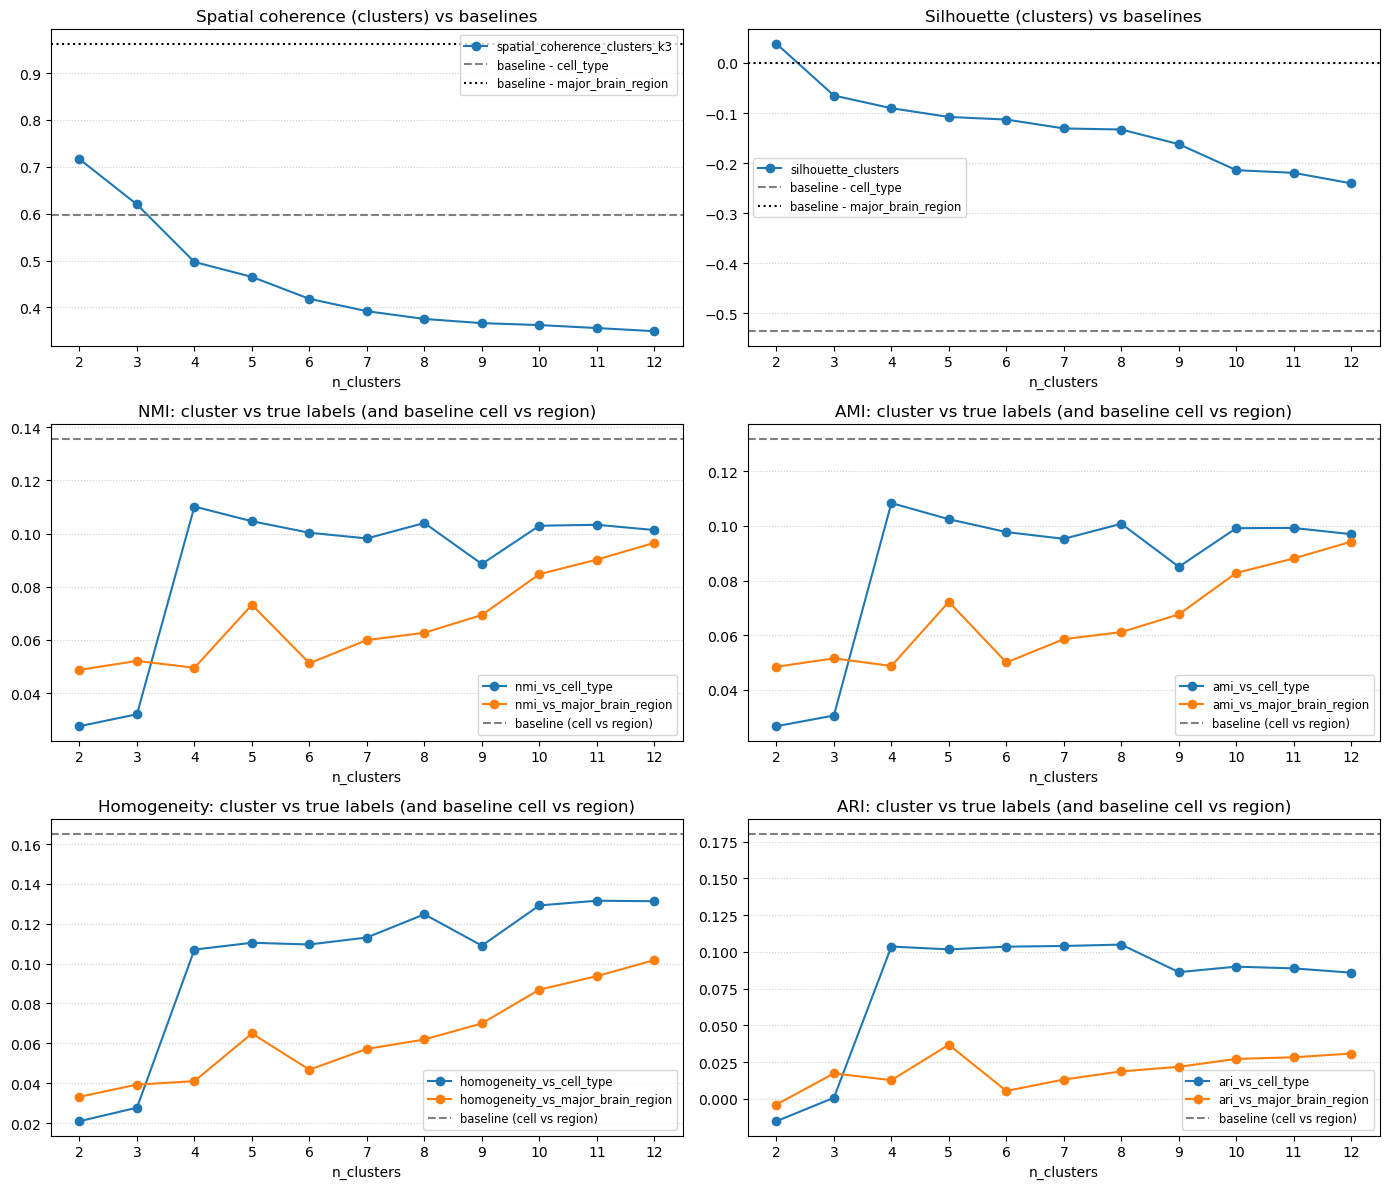

In [ ]:
import math

# Plot metrics across cluster counts and overlay baselines (use different color/linestyle per baseline)
metrics_plot_specs = [
    {
        "title": "Spatial coherence (clusters) vs baselines",
        "cols": ["spatial_coherence_clusters_k3"],
        "baselines": [
            ("baseline_spatial_coherence_cell_type", "baseline - cell_type"),
            ("baseline_spatial_coherence_major_brain_region", "baseline - major_brain_region"),
        ],
    },
    {
        "title": "Silhouette (clusters) vs baselines",
        "cols": ["silhouette_clusters"],
        "baselines": [
            ("baseline_silhouette_cell_type", "baseline - cell_type"),
            ("baseline_silhouette_major_brain_region", "baseline - major_brain_region"),
        ],
    },
    {
        "title": "NMI: cluster vs true labels (and baseline cell vs region)",
        "cols": ["nmi_vs_cell_type", "nmi_vs_major_brain_region"],
        "baselines": [("baseline_nmi_cell_vs_region", "baseline (cell vs region)")],
    },
    {
        "title": "AMI: cluster vs true labels (and baseline cell vs region)",
        "cols": ["ami_vs_cell_type", "ami_vs_major_brain_region"],
        "baselines": [("baseline_ami_cell_vs_region", "baseline (cell vs region)")],
    },
    {
        "title": "Homogeneity: cluster vs true labels (and baseline cell vs region)",
        "cols": ["homogeneity_vs_cell_type", "homogeneity_vs_major_brain_region"],
        "baselines": [("baseline_homogeneity_cell_vs_region", "baseline (cell vs region)")],
    },
    {
        "title": "ARI: cluster vs true labels (and baseline cell vs region)",
        "cols": ["ari_vs_cell_type", "ari_vs_major_brain_region"],
        "baselines": [("baseline_ari_cell_vs_region", "baseline (cell vs region)")],
    },
]

n_plots = len(metrics_plot_specs)
ncols = 2
nrows = math.ceil(n_plots / ncols)
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(14, 4 * nrows), squeeze=False)

# styling for baselines (will cycle if more than provided)
baseline_colors = ["gray", "black", "tab:orange", "tab:green"]
baseline_linestyles = ["--", ":", "-.", "-"]

for i, spec in enumerate(metrics_plot_specs):
    ax = axes[i // ncols, i % ncols]
    # plot each metric column for clusters
    for col in spec["cols"]:
        ax.plot(results_df["n_clusters"], results_df[col], marker="o", label=col)

    # plot baseline(s) as horizontal lines with distinct style/color per baseline
    for j, (bl_col, bl_label) in enumerate(spec.get("baselines", [])):
        if bl_col in results_df.columns:
            bl_val = float(results_df[bl_col].iloc[0])
            color = baseline_colors[j % len(baseline_colors)]
            ls = baseline_linestyles[j % len(baseline_linestyles)]
            ax.axhline(bl_val, color=color, linestyle=ls, linewidth=1.5, label=bl_label)

    ax.set_xlabel("n_clusters")
    ax.set_xticks(results_df["n_clusters"])
    ax.set_title(spec["title"])
    ax.legend(loc="best", fontsize="small")
    ax.grid(axis="y", linestyle=":", alpha=0.6)

# hide any unused subplots
total_axes = nrows * ncols
for j in range(n_plots, total_axes):
    fig.delaxes(axes[j // ncols, j % ncols])

fig.tight_layout()
plt.show()

## 3. Model Classification (Regression performance)

In [80]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import roc_auc_score, roc_curve

In [66]:
#True label
obskey1 = lrdata.obs["major_brain_region"]

#Factor values
factors = model.get_factors()["group_1"]
factors['anno'] = obskey1.reindex(factors.index)
factors = factors.dropna()
print(factors['anno'].isna().sum())
len(factors)

0


11732

In [69]:
X = factors.drop(columns=[ 'anno']).values

In [70]:
anno = factors["anno"].values

In [78]:
### Create X and Y objects
### Train multinomial logistic regression
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
   X, anno, test_size=0.3, random_state=42, stratify=anno
)
clf = LogisticRegression(
    solver="lbfgs",
    max_iter=1000,
    class_weight="balanced"
)
clf.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

### Evaluate the model

In [79]:
# Evaluate
y_pred = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.34005681818181815

Classification Report:
                      precision    recall  f1-score   support

  Cortical_subplate       0.24      0.37      0.29       213
       Fiber_tracts       0.10      0.33      0.16       110
        Hippocampus       0.02      0.50      0.03         6
       Hypothalamus       0.37      0.32      0.34       430
          Isocortex       0.68      0.39      0.49      1318
          Olfactory       0.24      0.36      0.29       264
           Pallidum       0.02      0.15      0.03        27
           Striatum       0.50      0.26      0.34       768
           Thalamus       0.42      0.37      0.39       352
Ventricular_systems       0.02      0.09      0.03        32

           accuracy                           0.34      3520
          macro avg       0.26      0.31      0.24      3520
       weighted avg       0.49      0.34      0.39      3520



#### 1. If threr are 2 classes only (healthy vs. disease)

In [ ]:
y_pred_proba = clf.predict_proba(X_test)[:, 1]

# Calculate AUC
auc = roc_auc_score(y_test, y_pred_proba)
print("AUC:", auc)


fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba, pos_label="222_REF")
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

#### 2. If classes are more than 2:

In [81]:
# Get class probabilities 
y_proba = clf.predict_proba(X_test)  

# Compute macro-average AUC (each class equally weighted)
auc_macro = roc_auc_score(y_test, y_proba, multi_class="ovr", average="macro")
print(f"Multiclass ROC AUC (OvR, macro): {auc_macro:.4f}")

# weights by class support:
auc_weighted = roc_auc_score(y_test, y_proba, multi_class="ovr", average="weighted")
print(f"Multiclass ROC AUC (OvR, weighted): {auc_weighted:.4f}")


Multiclass ROC AUC (OvR, macro): 0.7457
Multiclass ROC AUC (OvR, weighted): 0.7375
